# Parking Lot Entry Booth: Discrete-Event Simulation Study
**CSS142P Modelling and Simulation · Group 8** (Ariola, Bauza, Caliliw, Jimenez)
School of Information Technology, Mapúa University

**Decision question.** On high-traffic days, should the Makati campus parking lot keep one entry booth all day, staff a second booth from 07:00 to 09:00, or staff it from 07:00 to 10:00? The third option tests whether 09:00 is the right time to close the second booth, rather than assuming it.

**Measures (proposal Part 4).** Average waiting time (min), maximum queue length (vehicles), booth utilization over staffed booth-time, and spillover duration (minutes the queue holds at least *K* vehicles).

This notebook follows the 10-step study process: input modelling → conceptual model → verification → experiment → output analysis → validation → sensitivity → report. Section 5.5 adds a continuous fluid-flow model (Euler and RK4) as an independent cross-check of the DES queue profile. All model logic lives in `parking_sim.py`; this notebook only calls it, so every number below can be regenerated from the files in `data/`.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import parking_sim as ps

DATA, RESULTS, FIGS = Path("data"), Path("results"), Path("figures")
RESULTS.mkdir(exist_ok=True); FIGS.mkdir(exist_ok=True)

N_REPS = 30                         # proposal Part 6
SEEDS = list(range(1, N_REPS + 1))  # one seed per replication, shared by every configuration (CRN)
COLORS = dict(zip([c.name for c in ps.CONFIGS], ["tab:red", "tab:green", "tab:blue"]))
SHORT = dict(zip([c.name for c in ps.CONFIGS], ["1 booth", "2 booths\n07-09", "2 booths\n07-10"]))
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

site = pd.read_csv(DATA / "site_measurements.csv").iloc[0]
PLACEHOLDER = str(site["measured_on"]).strip().upper() == "PLACEHOLDER"
if PLACEHOLDER:
    print("WARNING: data/ still contains PLACEHOLDER inputs. The pipeline runs, but results are\n"
          "illustrative only until the gate log, stopwatch timings, and site measurement are replaced.")

illustrative only until the gate log, stopwatch timings, and site measurement are replaced.


## 1. Input modelling
### 1.1 Arrivals: piecewise-constant Poisson rates
Arrivals per 15-minute interval come from the gate entry log. If `data/peak_arrival_tally.csv` contains counts, they replace the log for those intervals. This matters because the gate log timestamps the moment a vehicle **passes the booth**, not when it joins the queue. While a queue exists, passages per interval are capped by booth capacity, so the log under-counts true peak demand. A tally taken at the tail of the queue records real arrivals.

Each interval's rate is λ = count / 15 vehicles per minute.

In [2]:
arr = ps.load_arrival_counts(DATA / "gate_entry_log.csv", DATA / "peak_arrival_tally.csv")
rates = arr["rate_per_min"].to_numpy()
print(f"Vehicles in log: {arr['count'].sum()}   |   07:00-09:00: {arr['count'][:8].sum()}   |   "
      f"sources used: {', '.join(arr['source'].unique())}")
arr.head(10)

Vehicles in log: 453   |   07:00-09:00: 220   |   sources used: gate log


,interval_start,t_start_min,count,source,rate_per_min
0,07:00,0.0,17,gate log,1.133
1,07:15,15.0,31,gate log,2.067
2,07:30,30.0,42,gate log,2.800
3,07:45,45.0,38,gate log,2.533
4,08:00,60.0,29,gate log,1.933
5,08:15,75.0,19,gate log,1.267
6,08:30,90.0,25,gate log,1.667
7,08:45,105.0,19,gate log,1.267
8,09:00,120.0,14,gate log,0.933
9,09:15,135.0,10,gate log,0.667


### 1.2 Processing (service) times
Sixty stopwatch timings: 30 in the peak window and 30 off-peak. Following the input-modelling steps (inspect → choose candidates → estimate → assess), the three candidate families named in the proposal are fitted to each window. If the windows do not differ, they are fitted to the pooled 60 timings instead. A family is chosen by this rule: among fits **not rejected** by the chi-square test at 5%, take the lowest AIC.

First, check whether peak and off-peak times differ enough to need separate distributions (Mann–Whitney U test).

In [3]:
svc = pd.read_csv(DATA / "service_times.csv")
svc["service_min"] = svc["service_sec"] / 60
peak_x = svc.loc[svc.window == "peak", "service_min"].to_numpy()
off_x  = svc.loc[svc.window == "offpeak", "service_min"].to_numpy()

display(svc.groupby("window")["service_sec"].describe().round(1))
mw = stats.mannwhitneyu(peak_x, off_x, alternative="two-sided")
SEPARATE = mw.pvalue < 0.05
print(f"Mann-Whitney U = {mw.statistic:.0f}, p = {mw.pvalue:.4f} -> "
      + ("peak and off-peak times differ: fit each window separately."
         if SEPARATE else "no evidence of a difference: pool all 60 timings into one distribution."))

,count,mean,std,min,25%,50%,75%,max
window,,,,,,,,
offpeak,30.0,31.4,12.4,11.9,24.5,28.8,36.9,69.5
peak,30.0,27.4,9.2,9.1,22.0,25.8,35.0,48.9


Mann-Whitney U = 368, p = 0.2282 -> no evidence of a difference: pool all 60 timings into one distribution.


In [4]:
samples = {"peak": peak_x, "offpeak": off_x} if SEPARATE else {"pooled": np.r_[peak_x, off_x]}

def service_model(family):
    # family: one name for all windows, or a dict {window: name}
    d = {w: ps.fit_distribution(x, family[w] if isinstance(family, dict) else family) for w, x in samples.items()}
    return ps.ServiceModel(d if SEPARATE else {"peak": d["pooled"], "offpeak": d["pooled"]})

fit_tables, chosen = [], {}
for w, x in samples.items():
    best, tab = ps.select_distribution(x)
    tab.insert(0, "window", w)
    fit_tables.append(tab); chosen[w] = best
fit_summary = pd.concat(fit_tables, ignore_index=True)
fit_summary.to_csv(RESULTS / "input_fit_summary.csv", index=False)

SERVICE = service_model(chosen)
print("Selected:", chosen)
fit_summary[["window","family","chi2","dof","chi2_crit_5pct","chi2_p","ks_p","aic","fit_mean","sample_mean","selected"]]

Selected: {'pooled': 'lognormal'}


,window,family,chi2,dof,chi2_crit_5pct,chi2_p,ks_p,aic,fit_mean,sample_mean,selected
0,pooled,exponential,68.333,8,15.507,1.054e-11,4.355e-07,36.446,0.490,0.49,False
1,pooled,lognormal,14.000,7,14.067,5.118e-02,6.994e-01,-35.189,0.492,0.49,True
2,pooled,triangular,15.667,6,12.592,1.566e-02,1.820e-03,-23.483,0.560,0.49,False


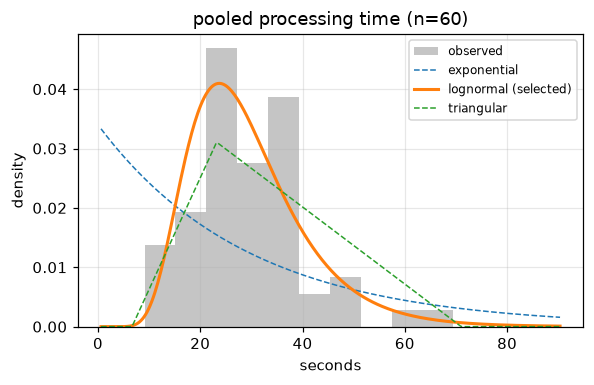

In [5]:
fig, axes = plt.subplots(1, len(samples), figsize=(5.5 * len(samples), 3.6), sharey=True)
for ax, (w, x) in zip(np.atleast_1d(axes), samples.items()):
    ax.hist(x * 60, bins=10, density=True, alpha=0.45, color="grey", label="observed")
    grid = np.linspace(0.01, x.max() * 1.3, 300)
    for fam in ps.CANDIDATES:
        d = ps.fit_distribution(x, fam)
        ax.plot(grid * 60, d.pdf(grid) / 60, lw=2 if fam == chosen[w] else 1,
                ls="-" if fam == chosen[w] else "--", label=fam + (" (selected)" if fam == chosen[w] else ""))
    ax.set_title(f"{w} processing time (n={len(x)})"); ax.set_xlabel("seconds")
np.atleast_1d(axes)[0].set_ylabel("density"); np.atleast_1d(axes)[-1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "service_time_fits.png"); plt.show()

With only 30 to 60 observations, goodness-of-fit tests have low power: "not rejected" does not mean "proven correct". Section 8.2 therefore reruns the study under every candidate family to check whether the choice changes the recommendation.

### 1.3 Approach capacity *K*
*K* = usable approach length ÷ (average vehicle length + gap), rounded down: the number of vehicles that fit before the tail reaches Pablo Ocampo Sr. Extension.

In [6]:
K = int(site["approach_length_m"] // (site["avg_vehicle_length_m"] + site["avg_gap_m"]))
print(f"{site['approach_length_m']} m / ({site['avg_vehicle_length_m']} + {site['avg_gap_m']}) m  ->  K = {K} vehicles")

30.0 m / (4.6 + 1.4) m  ->  K = 5 vehicles


### 1.4 Load check before simulating: utilization by interval
For each interval, offered load is ρ = λ · E[S] / c. The Week 2 lesson applies: as ρ approaches 1, delay grows sharply, and when ρ > 1 the queue must grow for that whole interval. This analytic screen shows *where* trouble should appear. The simulation then measures *how much*.

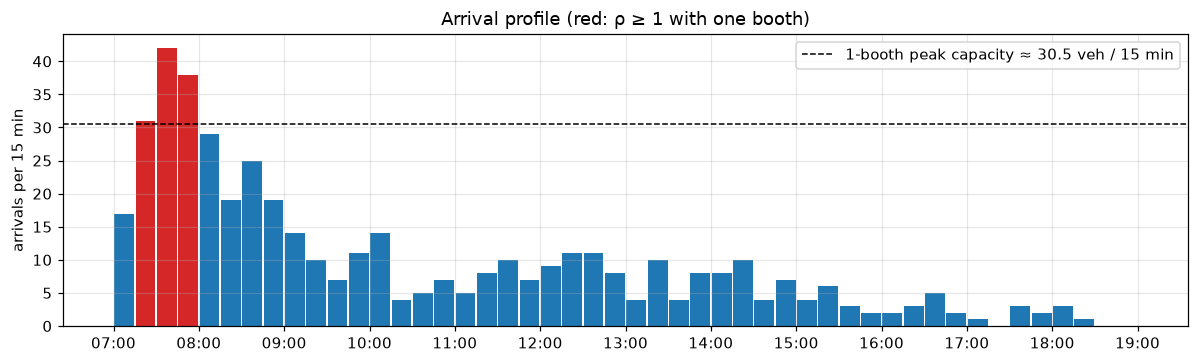

,interval_start,count,rate_per_min,rho_1_booth,rho_2_booths
0,07:00,17,1.133,0.557,0.279
1,07:15,31,2.067,1.016,0.508
2,07:30,42,2.800,1.377,0.689
3,07:45,38,2.533,1.246,0.623
4,08:00,29,1.933,0.951,0.475
5,08:15,19,1.267,0.623,0.311
6,08:30,25,1.667,0.820,0.410
7,08:45,19,1.267,0.623,0.311
8,09:00,14,0.933,0.459,0.230
9,09:15,10,0.667,0.328,0.164


In [7]:
arr["mean_service_min"] = np.where(arr["t_start_min"] < ps.PEAK_END, SERVICE.dists["peak"].mean(), SERVICE.dists["offpeak"].mean())
arr["rho_1_booth"] = arr["rate_per_min"] * arr["mean_service_min"]
arr["rho_2_booths"] = arr["rho_1_booth"] / 2          # load if both booths are open in that interval
arr.to_csv(RESULTS / "arrival_rates_and_load.csv", index=False)

cap1 = 1 / SERVICE.dists["peak"].mean() * 15
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(arr["t_start_min"] + 7.5, arr["count"], width=14, color=["tab:red" if r >= 1 else "tab:blue" for r in arr["rho_1_booth"]])
ax.axhline(cap1, color="k", ls="--", lw=1, label=f"1-booth peak capacity ≈ {cap1:.1f} veh / 15 min")
ax.set_xticks(np.arange(0, 721, 60)); ax.set_xticklabels([ps.min_to_clock(t) for t in range(0, 721, 60)])
ax.set_ylabel("arrivals per 15 min"); ax.set_title("Arrival profile (red: ρ ≥ 1 with one booth)"); ax.legend()
plt.tight_layout(); plt.savefig(FIGS / "arrival_profile.png"); plt.show()
arr.loc[:13, ["interval_start","count","rate_per_min","rho_1_booth","rho_2_booths"]]   # 07:00-10:30

## 2. Conceptual model
**Classification.** The model is **dynamic** because the order and timing of arrivals determine waiting. It is **stochastic** because interarrival and processing times vary. It is **discrete** because queue length and booth status change only at events. (The fluid model in Section 5.5 is a separate, continuous approximation used only as a cross-check. The study model is the DES.)

| Element | In this model |
|---|---|
| Entity | vehicle (attributes: arrival time, processing time) |
| Resource | entry booth(s); one vehicle at a time each |
| State | vehicles waiting; each booth busy/idle and open/closed |
| Events | arrival · processing start · processing completion · second-booth closing (09:00 or 10:00, depending on the configuration) |
| Activity (sampled) | processing time |
| Delay (output) | time in queue |
| Study type | **terminating**: 07:00 start empty, arrivals stop 19:00, queue cleared. No warm-up is discarded because the empty start is the real condition being studied. |

**Assumptions** (C = confirmed fact, P = provisional modelling choice):

| # | Assumption | Status | Reason / effect |
|---|---|---|---|
| A1 | Arrivals are Poisson with a rate that is constant within each 15-min interval | P | Standard for independent arrivals; rate changes capture the peak. Tested by sensitivity on arrival scale. |
| A2 | Processing time depends on arrival window (peak/off-peak), fitted from stopwatch data | P | Section 1.2. Tested by distribution-family sensitivity. |
| A3 | Both two-booth configurations use **one shared queue** that feeds whichever booth frees first | P | Proposal does not specify the lane layout. A shared queue is the best case; two separate lanes where drivers choose would do somewhat worse. |
| A4 | At its closing time (09:00 or 10:00) the second booth finishes its current vehicle, then accepts no more | P | Non-preemptive close; staffed time extends to that finish. |
| A5 | Second booth draws processing times from the same distribution as the first | P | Stated in proposal Part 5. |
| A6 | No balking, reneging, parking-space limit, or exit interaction | C (scope) | Proposal Part 2, out of scope. |
| A7 | Queue is empty and booth idle at 07:00 | P | Proposal Part 2. If cars wait before opening, the real start is not empty (see limitations). |
| A8 | Spillover when the **waiting** queue (excluding the vehicle at the booth) holds ≥ *K* | P | Direct reading of the proposal's definition. |

## 3. Verification: did we build the model right?
Each check below compares the code with the design, not with the real system. All results are written to `results/verification_checks.csv`, and the checks should be rerun after every model change.

In [8]:
checks = []
def check(name, expected, observed, passed):
    checks.append({"check": name, "expected": str(expected), "observed": str(observed), "pass": bool(passed)})

# V1 - Hand trace from the DES lecture (interarrivals 2,4,1,3; services 3,2,4,1)
r = ps.simulate_day(np.array([2., 6, 7, 10]), np.array([3., 2, 4, 1]), ps.ONE_BOOTH)
w = r.start - r.arrival
check("V1 hand trace: delays", "[0, 0, 1, 2]", [float(v) for v in w], np.allclose(w, [0, 0, 1, 2]))
check("V1 hand trace: Wq and utilization", "Wq=0.75, util=10/13=0.769",
      f"Wq={w.mean():.2f}, util={r.booths[0].busy_time / r.finish.max():.3f}",
      np.isclose(w.mean(), 0.75) and np.isclose(r.booths[0].busy_time / r.finish.max(), 10 / 13))

# V2 - Deterministic queue from Week 2: arrival every 1.00 min, service 0.99 min -> no waiting
r = ps.simulate_day(np.arange(0, 100, 1.0), np.full(100, 0.99), ps.ONE_BOOTH)
check("V2 deterministic D/D/1 (Week 2): no wait", 0.0, float((r.start - r.arrival).max()), (r.start - r.arrival).max() == 0)

# V3-V8 on the real experiment inputs, every replication, every configuration
exp_df, days = ps.run_experiment(SEEDS, rates, SERVICE, K, keep_days=True, extra_K=(max(K - 1, 1), K + 1))
cons_ok = little_ok = sane_ok = close_ok = fifo_ok = crn_ok = True
for (seed, cfg), d in days.items():
    s = d.snapshot_close
    cons_ok &= s["arrived"] == s["finished"] + s["waiting"] + s["in_service"]
    cons_ok &= np.all(np.isfinite(d.finish))                           # everyone eventually served
    wait = d.start - d.arrival
    sane_ok &= wait.min() >= -1e-9 and d.trace_q.min() >= 0
    fifo_ok &= np.all(np.diff(d.start) >= -1e-9)                       # single queue, first come first served
    area = np.sum((np.append(d.trace_t[1:], d.trace_t[-1]) - d.trace_t) * d.trace_q)
    little_ok &= np.isclose(area, wait.sum(), rtol=1e-9)               # Lq*T = sum of delays (Little)
    if d.config.extra_booths:
        close_ok &= not np.any((d.booth == 2) & (d.start > d.config.extra_close + 1e-9))
for seed in SEEDS:
    a = days[(seed, ps.CONFIGS[0].name)]
    for cfg in ps.CONFIGS[1:]:
        b = days[(seed, cfg.name)]
        crn_ok &= np.array_equal(a.arrival, b.arrival) and np.allclose(a.finish - a.start, b.finish - b.start)
util_ok = exp_df["utilization"].between(0, 1).all() and exp_df["peak_utilization"].between(0, 1).all()

check(f"V3 conservation at 19:00: arrived = finished + waiting + in service (all {len(days)} runs)", "equal", "equal" if cons_ok else "MISMATCH", cons_ok)
check("V4 sanity: waits >= 0, queue >= 0, utilization in [0,1]", "true", sane_ok and util_ok, sane_ok and util_ok)
check("V5 FIFO: service starts in arrival order", "true", fifo_ok, fifo_ok)
check("V6 Little's law identity: queue-length area = sum of delays", "equal", little_ok, little_ok)
check("V7 second booth starts no vehicle after its closing time (09:00 or 10:00)", "0 starts", "0 starts" if close_ok else "violations", close_ok)
check("V8 common random numbers: all configs see identical arrivals and processing times", "identical", crn_ok, crn_ok)

**Known-answer tests (steady-state, separate from the main study).** With constant-rate Poisson arrivals and exponential service, queueing theory gives the exact long-run delay: M/M/1 (Week 2) and M/M/2 via Erlang C. These runs are steady-state studies, so a 1,000-minute warm-up is discarded. They exercise the same `simulate_day` code, including the two-booth path.

In [9]:
def known_answer(lam, mean_s, booths, reps=20, horizon=20000, warm=1000):
    cfg = ps.Config("test", base_booths=booths, extra_booths=0)
    est = []
    for seed in range(1000, 1000 + reps):
        rng = np.random.default_rng(seed)
        a = np.cumsum(rng.exponential(1 / lam, int(lam * horizon * 1.1)))
        a = a[a < horizon]
        d = ps.simulate_day(a, rng.exponential(mean_s, len(a)), cfg, day_length=horizon)
        keep = d.arrival >= warm
        est.append((d.start - d.arrival)[keep].mean())
    return ps.ci_mean(est)

for lam, mean_s, c in [(0.8, 1.0, 1), (1.6, 1.0, 2)]:
    theory = ps.mm1_wq(lam, 1 / mean_s) if c == 1 else ps.mmc_wq(lam, 1 / mean_s, c)
    ci = known_answer(lam, mean_s, c)
    check(f"V9 known answer M/M/{c} (lambda={lam}, E[S]={mean_s}): Wq",
          f"{theory:.3f} (theory)", f"{ci['mean']:.3f} [{ci['ci_low']:.3f}, {ci['ci_high']:.3f}]",
          ci["ci_low"] <= theory <= ci["ci_high"])

ver = pd.DataFrame(checks); ver.to_csv(RESULTS / "verification_checks.csv", index=False)
print(f"{ver['pass'].sum()} / {len(ver)} checks passed")
ver

11 / 11 checks passed


,check,expected,observed,pass
0,V1 hand trace: delays,"[0, 0, 1, 2]","[0.0, 0.0, 1.0, 2.0]",True
1,V1 hand trace: Wq and utilization,"Wq=0.75, util=10/13=0.769","Wq=0.75, util=0.769",True
2,V2 deterministic D/D/1 (Week 2): no wait,0.0,0.0,True
3,V3 conservation at 19:00: arrived = finished +...,equal,equal,True
4,"V4 sanity: waits >= 0, queue >= 0, utilization...",true,True,True
5,V5 FIFO: service starts in arrival order,true,True,True
6,V6 Little's law identity: queue-length area = ...,equal,True,True
7,V7 second booth starts no vehicle after its cl...,0 starts,0 starts,True
8,V8 common random numbers: all configs see iden...,identical,True,True
9,"V9 known answer M/M/1 (lambda=0.8, E[S]=1.0): Wq",4.000 (theory),"3.981 [3.838, 4.124]",True


## 4. Experiment design
| Item | Setting |
|---|---|
| Study type | Terminating, one operating day (07:00 to queue cleared after 19:00) |
| Warm-up | None (the empty 07:00 start is part of the question) |
| Configurations | 1 booth all day · 2 booths 07:00–09:00 · 2 booths 07:00–10:00 |
| Replications | 30 per configuration, seeds 1–30 |
| Variance reduction | Common random numbers: each seed produces one arrival stream and one processing-time stream, and all three configurations see exactly the same vehicles (verified in V8) |
| Analysis | 95% t-intervals per configuration, plus **paired**-t intervals on the per-seed difference for three comparisons: 1 booth vs 2 booths 07–09, 1 booth vs 2 booths 07–10, and 2 booths 07–09 vs 07–10 (does the extra hour add anything?) |

The experiment was already run inside the verification cell (`exp_df`); raw replication output is saved next.

In [10]:
exp_df.drop(columns=[c for c in exp_df.columns if c.startswith("_")]).to_csv(RESULTS / "replications_raw.csv", index=False)
exp_df[["seed","config","avg_wait_min","max_queue_veh","utilization","spillover_min","n_vehicles"]].head(6)

,seed,config,avg_wait_min,max_queue_veh,utilization,spillover_min,n_vehicles
0,1,1 booth all day,2.194,20,0.320,73.492,457
1,1,2 booths 07:00-09:00,0.151,5,0.274,0.768,457
2,1,2 booths 07:00-10:00,0.131,5,0.256,0.768,457
3,2,1 booth all day,3.228,29,0.311,81.770,450
4,2,2 booths 07:00-09:00,0.085,5,0.266,0.009,450
5,2,2 booths 07:00-10:00,0.072,5,0.249,0.009,450


## 5. Results
### 5.1 Each configuration: mean with 95% confidence interval (n = 30)

In [11]:
MEASURES = {  # column: (label, is proposal measure)
    "avg_wait_min": ("Average waiting time (min)", True),
    "max_queue_veh": ("Maximum queue length (vehicles)", True),
    "utilization": ("Booth utilization, staffed time (fraction)", True),
    "spillover_min": (f"Spillover duration, queue >= K={K} (min)", True),
    "avg_wait_peak_arrivals_min": ("Avg wait, vehicles arriving 07:00-09:00 (min)", False),
    "p90_wait_min": ("90th-percentile wait (min)", False),
    "peak_utilization": ("Utilization inside 07:00-09:00 (fraction)", False),
    "spillover_peak_min": ("Spillover inside 07:00-09:00 (min)", False),
    "vehicles_queued_on_road": ("Vehicles that joined the queue on the road", False),
}
rows = []
for cfg in [c.name for c in ps.CONFIGS]:
    sub = exp_df[exp_df.config == cfg]
    for col, (label, core) in MEASURES.items():
        rows.append({"configuration": cfg, "measure": label, "proposal_measure": core, **ps.ci_mean(sub[col])})
summary = pd.DataFrame(rows); summary.to_csv(RESULTS / "summary_by_config.csv", index=False)
summary.pivot(index="measure", columns="configuration", values="mean").join(
    summary.pivot(index="measure", columns="configuration", values="half_width").add_suffix(" ±hw")).round(3)

configuration,1 booth all day,2 booths 07:00-09:00,2 booths 07:00-10:00,1 booth all day ±hw,2 booths 07:00-09:00 ±hw,2 booths 07:00-10:00 ±hw
measure,,,,,,
90th-percentile wait (min),9.542,0.438,0.394,1.118,0.041,0.041
Average waiting time (min),2.720,0.113,0.099,0.400,0.011,0.011
"Avg wait, vehicles arriving 07:00-09:00 (min)",5.459,0.115,0.115,0.764,0.015,0.015
"Booth utilization, staffed time (fraction)",0.308,0.264,0.246,0.007,0.006,0.005
Maximum queue length (vehicles),26.800,4.633,4.633,2.603,0.410,0.410
"Spillover duration, queue >= K=5 (min)",71.189,0.334,0.331,6.353,0.303,0.303
Spillover inside 07:00-09:00 (min),70.575,0.331,0.331,6.040,0.303,0.303
Utilization inside 07:00-09:00 (fraction),0.879,0.443,0.443,0.021,0.012,0.012
Vehicles that joined the queue on the road,140.067,0.567,0.567,12.606,0.725,0.725


### 5.2 Paired comparisons using common random numbers
Because each seed gives every configuration the same day of traffic, the right comparison is the per-seed difference *D = A − B*. Three comparisons are reported:

1. **1 booth − 2 booths 07–09**: does a second booth during the peak help?
2. **1 booth − 2 booths 07–10**: the same question for the longer option.
3. **2 booths 07–09 − 2 booths 07–10**: does the **extra hour** from 09:00 to 10:00 add anything?

If the 95% interval for D excludes 0, the difference is statistically significant. Three intervals are read together, so the chance that *at least one* excludes 0 by luck is higher than 5%. The `significant_bonferroni` column applies the simple Bonferroni correction: each interval is built at 1 − 0.05/3 ≈ 98.3%, so the three conclusions hold jointly at 95%.

**Significant is not the same as important.** CRN makes comparisons very precise, so a difference of a second or two can be statistically significant. The decision should rest on whether the size of the difference matters, for example minutes of spillover, not only on whether its interval excludes 0.

In [12]:
by_cfg = {c.name: exp_df[exp_df.config == c.name].set_index("seed").sort_index() for c in ps.CONFIGS}
N_COMP = len(ps.COMPARISONS)
prow = []
for a, b in ps.COMPARISONS:
    A, B = by_cfg[a.name], by_cfg[b.name]
    for col, (label, core) in MEASURES.items():
        d = A[col] - B[col]
        ci = ps.ci_mean(d)
        ci_bonf = ps.ci_mean(d, conf=1 - 0.05 / N_COMP)
        indep = ps.ci_mean(A[col])["se"] ** 2 + ps.ci_mean(B[col])["se"] ** 2
        prow.append({"comparison": f"{a.name} - {b.name}", "measure": label, "proposal_measure": core,
                     "mean_A": A[col].mean(), "mean_B": B[col].mean(),
                     "diff_mean": ci["mean"], "diff_ci_low": ci["ci_low"], "diff_ci_high": ci["ci_high"],
                     "significant_5pct": not (ci["ci_low"] <= 0 <= ci["ci_high"]),
                     "significant_bonferroni": not (ci_bonf["ci_low"] <= 0 <= ci_bonf["ci_high"]),
                     "variance_reduction_vs_independent": 1 - ci["se"] ** 2 / indep if indep > 0 else np.nan})
paired = pd.DataFrame(prow); paired.to_csv(RESULTS / "paired_differences.csv", index=False)
paired[paired.proposal_measure].drop(columns="proposal_measure").round(3)

,comparison,measure,mean_A,mean_B,diff_mean,diff_ci_low,diff_ci_high,significant_5pct,significant_bonferroni,variance_reduction_vs_independent
0,1 booth all day - 2 booths 07:00-09:00,Average waiting time (min),2.720,0.113,2.608,2.209,3.007,True,True,0.006
1,1 booth all day - 2 booths 07:00-09:00,Maximum queue length (vehicles),26.800,4.633,22.167,19.565,24.769,True,True,0.025
2,1 booth all day - 2 booths 07:00-09:00,"Booth utilization, staffed time (fraction)",0.308,0.264,0.044,0.043,0.045,True,True,0.988
3,1 booth all day - 2 booths 07:00-09:00,"Spillover duration, queue >= K=5 (min)",71.189,0.334,70.855,64.505,77.206,True,True,0.003
9,1 booth all day - 2 booths 07:00-10:00,Average waiting time (min),2.720,0.099,2.622,2.223,3.020,True,True,0.008
10,1 booth all day - 2 booths 07:00-10:00,Maximum queue length (vehicles),26.800,4.633,22.167,19.565,24.769,True,True,0.025
11,1 booth all day - 2 booths 07:00-10:00,"Booth utilization, staffed time (fraction)",0.308,0.246,0.062,0.060,0.063,True,True,0.975
12,1 booth all day - 2 booths 07:00-10:00,"Spillover duration, queue >= K=5 (min)",71.189,0.331,70.859,64.508,77.210,True,True,0.003
18,2 booths 07:00-09:00 - 2 booths 07:00-10:00,Average waiting time (min),0.113,0.099,0.014,0.010,0.018,True,True,0.946
19,2 booths 07:00-09:00 - 2 booths 07:00-10:00,Maximum queue length (vehicles),4.633,4.633,0.000,0.000,0.000,False,False,1.000


`variance_reduction_vs_independent` compares the variance of the paired difference with what independent seeds would give: Var(D) = Var(A) + Var(B) − 2·Cov(A, B). CRN helps only through that covariance term. When one configuration barely varies from day to day (the two-booth waits are close to zero on every seed), there is little covariance to exploit, so the reduction is small. For utilization, where both configurations move together with the day's traffic, CRN removes almost all of the noise.

### 5.3 Monte Carlo estimate: probability that a high-traffic day has any spillover
Each replication is one simulated high-traffic day. The share of days with at least one minute of queue ≥ *K* estimates that probability, reported with a Wilson 95% interval.

In [13]:
mc = []
for cfg in [c.name for c in ps.CONFIGS]:
    k = int(exp_df.loc[exp_df.config == cfg, "any_spillover"].sum())
    p, lo, hi = ps.wilson_interval(k, N_REPS)
    mc.append({"configuration": cfg, "days_with_spillover": k, "days": N_REPS, "p_hat": p, "ci_low": lo, "ci_high": hi})
mc = pd.DataFrame(mc); mc.to_csv(RESULTS / "spillover_probability.csv", index=False); mc.round(3)

,configuration,days_with_spillover,days,p_hat,ci_low,ci_high
0,1 booth all day,30,30,1.000,0.886,1.000
1,2 booths 07:00-09:00,16,30,0.533,0.361,0.698
2,2 booths 07:00-10:00,16,30,0.533,0.361,0.698


### 5.4 When does the queue form? Time-average queue length by 15-minute interval

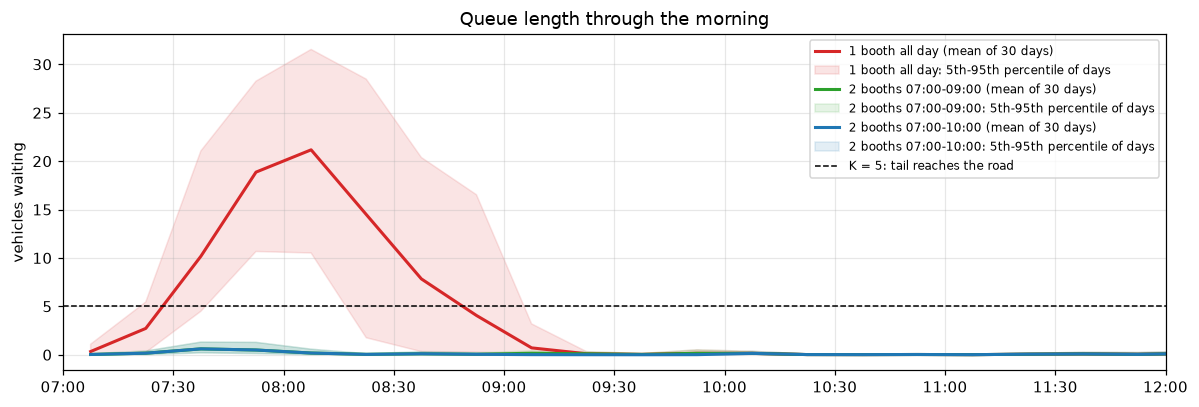

In [14]:
edges = np.arange(0, ps.DAY_LENGTH + ps.INTERVAL, ps.INTERVAL)
prof = {}
for cfg in [c.name for c in ps.CONFIGS]:
    prof[cfg] = np.array([ps.mean_queue_by_interval(days[(s, cfg)], edges) for s in SEEDS])
profile = pd.DataFrame({"interval_start": [ps.min_to_clock(t) for t in edges[:-1]]})
for cfg, m in prof.items():
    profile[f"{cfg} | mean"] = m.mean(0)
    profile[f"{cfg} | p05"] = np.percentile(m, 5, 0)
    profile[f"{cfg} | p95"] = np.percentile(m, 95, 0)
profile.to_csv(RESULTS / "queue_profile_by_interval.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 3.8))
x = edges[:-1] + 7.5
for cfg, m in prof.items():
    col = COLORS[cfg]
    ax.plot(x, m.mean(0), color=col, lw=2, label=f"{cfg} (mean of {N_REPS} days)")
    ax.fill_between(x, np.percentile(m, 5, 0), np.percentile(m, 95, 0), color=col, alpha=0.12, label=f"{cfg}: 5th-95th percentile of days")
ax.axhline(K, color="k", ls="--", lw=1, label=f"K = {K}: tail reaches the road")
ax.set_xlim(0, 300); ax.set_xticks(np.arange(0, 301, 30)); ax.set_xticklabels([ps.min_to_clock(t) for t in range(0, 301, 30)])
ax.set_ylabel("vehicles waiting"); ax.set_title("Queue length through the morning"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "queue_profile.png"); plt.show()

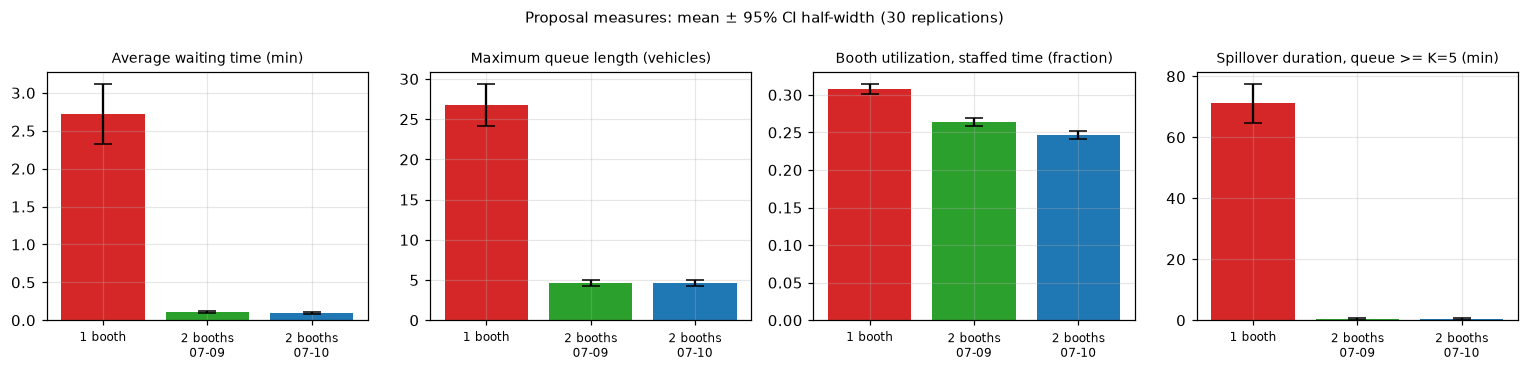

In [15]:
core = summary[summary.proposal_measure]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
for ax, (lab, g) in zip(axes, core.groupby("measure", sort=False)):
    ax.bar(range(len(g)), g["mean"], yerr=g["half_width"], capsize=6, color=[COLORS[c] for c in g["configuration"]])
    ax.set_xticks(range(len(g))); ax.set_xticklabels([SHORT[c] for c in g["configuration"]], fontsize=8); ax.set_title(lab, fontsize=9)
plt.suptitle("Proposal measures: mean ± 95% CI half-width (30 replications)", fontsize=10)
plt.tight_layout(); plt.savefig(FIGS / "measures_ci.png"); plt.show()

### 5.5 Continuous cross-check: fluid-flow approximation
The DES is the study model. As an independent check on its morning queue profile, the same inputs are fed to a **continuous** model, the fluid-flow approximation used in traffic and teletraffic engineering. It treats the expected number of vehicles in the system, *x*(*t*), as a smoothly varying level:

$$\frac{dx}{dt} = \lambda(t) - \frac{c(t)\,\rho(x)}{E[S]}$$

- λ(*t*): the same piecewise-constant arrival rates as the DES.
- *c*(*t*): booths open (2 → 1 at 09:00 or 10:00 in the two-booth configurations).
- ρ(*x*): the utilization at which a steady-state queue would hold *x* vehicles on average. It is found by inverting *L* = *c*ρ + *L*<sub>q</sub>(ρ), where *L*<sub>q</sub> is Erlang C scaled by (1 + SCV<sub>S</sub>)/2. For one booth this is exactly the Pollaczek–Khinchine formula.
- The level is converted to vehicles *waiting* by *L*<sub>q</sub>(*t*) = *x* − *c*ρ(*x*), the same quantity the DES reports.

A **deterministic fluid** version, where booths drain at full rate whenever there is a backlog, is also run. It is the continuous analogue of the Week 2 deterministic queue: no variability, so a queue forms only while arrivals exceed capacity.

This model is an approximation. It is pointwise-stationary: it assumes each instant behaves like a steady-state queue. It reports only a mean, so it cannot give the maximum queue, the spillover probability, or the spread of days, and those are why the study uses DES. It is included for two reasons. It is a second, independently derived estimate of the queue profile. And it gives a rate equation to which the Euler and Runge–Kutta step-size checks apply.

**Numerical method check.** Both methods are run over 07:00–09:00 with halving step sizes and compared with RK4 at *h* = 0.05 min. Step sizes that divide 15 minutes keep every rate change on a step boundary.

In [16]:
f1 = ps.fluid_rhs_factory(rates, ps.ONE_BOOTH, SERVICE)
t_ref, x_ref = ps.integrate(f1, 0, ps.PEAK_END, 0.05, "rk4")
ref_0800 = x_ref[int(round(60 / 0.05))]
step = []
for h in [15, 7.5, 5, 2.5, 1.25, 0.625]:
    for method in ["euler", "rk4"]:
        t_, x_ = ps.integrate(f1, 0, ps.PEAK_END, h, method)
        v = x_[int(round(60 / h))]
        step.append({"h_min": h, "method": method, "x_at_0800": v, "abs_error": abs(v - ref_0800)})
step = pd.DataFrame(step)
step.to_csv(RESULTS / "fluid_step_size.csv", index=False)
print(f"Reference (RK4, h = 0.05 min): x(08:00) = {ref_0800:.3f} vehicles in system, 1 booth")
step.pivot(index="h_min", columns="method", values="abs_error").sort_index(ascending=False).round(4)

Reference (RK4, h = 0.05 min): x(08:00) = 27.429 vehicles in system, 1 booth


method,euler,rk4
h_min,,
15.000,11.614,1.133
7.500,1.710,0.550
5.000,4.472,0.256
2.500,0.643,0.011
1.250,0.278,0.009
0.625,0.131,0.005


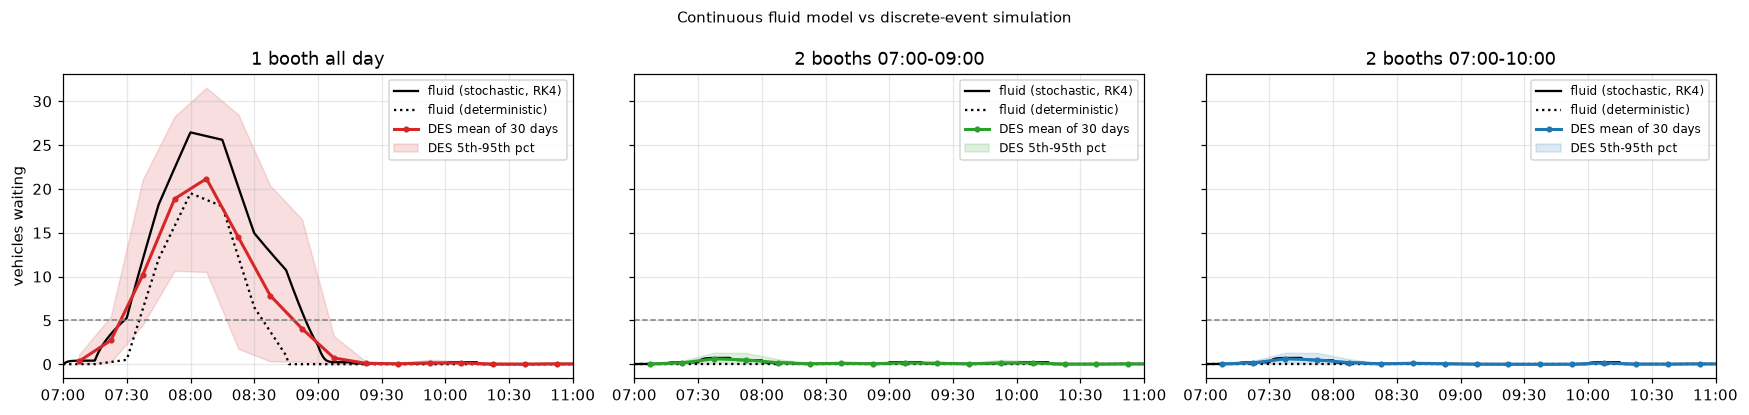

,configuration,model,peak_interval,peak_interval_mean_queue,mean_queue_0700_0900
0,1 booth all day,"fluid (stochastic, RK4)",08:00,26.02,12.88
1,1 booth all day,fluid (deterministic),08:00,18.75,7.14
2,1 booth all day,DES mean,08:00,21.17,9.96
3,2 booths 07:00-09:00,"fluid (stochastic, RK4)",07:30,0.66,0.21
4,2 booths 07:00-09:00,fluid (deterministic),07:00,0.00,0.00
5,2 booths 07:00-09:00,DES mean,07:30,0.61,0.21
6,2 booths 07:00-10:00,"fluid (stochastic, RK4)",07:30,0.66,0.21
7,2 booths 07:00-10:00,fluid (deterministic),07:00,0.00,0.00
8,2 booths 07:00-10:00,DES mean,07:30,0.61,0.21


In [17]:
H = 0.25                                    # RK4 step (min); the table above shows it is well converged
fluid_prof = pd.DataFrame({"interval_start": profile["interval_start"]})
fig, axes = plt.subplots(1, len(ps.CONFIGS), figsize=(16, 3.8), sharey=True)
for ax, cfg in zip(axes, ps.CONFIGS):
    col = COLORS[cfg.name]
    for det, ls, lab in [(False, "-", "fluid (stochastic, RK4)"), (True, ":", "fluid (deterministic)")]:
        f = ps.fluid_rhs_factory(rates, cfg, SERVICE, deterministic=det)
        t_, x_ = ps.integrate(f, 0, ps.DAY_LENGTH, H, "rk4")
        q_ = ps.fluid_queue(t_, x_, f, deterministic=det)
        # time-average per 15-min interval, same basis as the DES profile
        avg = []
        for a in edges[:-1]:
            m = (t_ >= a) & (t_ <= a + ps.INTERVAL)
            avg.append(np.sum(np.diff(t_[m]) * (q_[m][1:] + q_[m][:-1]) / 2) / ps.INTERVAL)
        fluid_prof[f"{cfg.name} | {lab}"] = avg
        ax.plot(t_, q_, color="k", ls=ls, lw=1.5, label=lab)
    fluid_prof[f"{cfg.name} | DES mean"] = profile[f"{cfg.name} | mean"]
    ax.plot(edges[:-1] + 7.5, profile[f"{cfg.name} | mean"], color=col, lw=2, marker="o", ms=3, label=f"DES mean of {N_REPS} days")
    ax.fill_between(edges[:-1] + 7.5, profile[f"{cfg.name} | p05"], profile[f"{cfg.name} | p95"], color=col, alpha=0.15, label="DES 5th-95th pct")
    ax.axhline(K, color="grey", ls="--", lw=1)
    ax.set_xlim(0, 240); ax.set_xticks(np.arange(0, 241, 30)); ax.set_xticklabels([ps.min_to_clock(t) for t in range(0, 241, 30)])
    ax.set_title(cfg.name); ax.legend(fontsize=8)
axes[0].set_ylabel("vehicles waiting")
plt.suptitle("Continuous fluid model vs discrete-event simulation", fontsize=10)
plt.tight_layout(); plt.savefig(FIGS / "fluid_cross_check.png"); plt.show()
fluid_prof.to_csv(RESULTS / "fluid_vs_des.csv", index=False)

cmp = []
morning = fluid_prof.iloc[:8]                                      # 07:00-09:00
for cfg in [c.name for c in ps.CONFIGS]:
    for lab in ["fluid (stochastic, RK4)", "fluid (deterministic)", "DES mean"]:
        col_ = morning[f"{cfg} | {lab}"]
        cmp.append({"configuration": cfg, "model": lab, "peak_interval": morning.loc[col_.idxmax(), "interval_start"],
                    "peak_interval_mean_queue": col_.max(), "mean_queue_0700_0900": col_.mean()})
pd.DataFrame(cmp).round(2)

**Reading the cross-check.**
- **Agreement on shape.** If the stochastic fluid curve peaks in the same interval as the DES mean and shows the same qualitative gap between one and two booths, two independently built models agree on *when* the queue forms and *how much* a second booth removes. That is evidence the DES logic is right. It is not proof that either model matches the real gate, which is the job of Section 7.
- **The deterministic fluid sits below the DES.** It builds a queue only in the intervals where ρ > 1 (Section 1.4) and none at all with two booths. This is the Week 2 lesson in continuous form: with the same mean rates, variability alone creates the extra waiting, so a model that averages it away understates congestion.
- **The stochastic fluid is not exact.** Pointwise-stationary fluid models are known to overshoot during a fast build-up and to lag the recovery, because the real queue never reaches steady state within a 15-minute interval. Differences of a few vehicles at the peak are expected, and the DES remains the model of record.
- **Numerical accuracy.** For small steps (*h* ≤ 2.5 min), Euler's error roughly halves each time *h* halves, which is first-order behaviour. At large steps it is erratic: a 15-min step overshoots by more than 10 vehicles, and 5 min does worse than 7.5 min, because the step no longer tracks the fast build-up. That is the accuracy-and-stability point from the continuous-simulation lecture. RK4 is far more accurate at every step size. It does not show clean fourth-order convergence here because λ(*t*) jumps at interval boundaries and the level is floored at zero, so the right-hand side is not smooth. The profile above uses RK4 with *h* = 0.25 min, well inside the converged range.

## 6. Were 30 replications enough?
Week 7 rule: *n* needed = *n* × (half-width now ÷ half-width wanted)², rounded up. The targets are **absolute precisions chosen from the decision**: waits to within ±0.25 min, spillover to within ±5 min, maximum queue to within ±2 vehicles, and utilization to within ±0.02. They apply to each configuration and to each of the three paired differences, which are the quantities the decision actually rests on.

In [18]:
TARGET = {"avg_wait_min": 0.25, "spillover_min": 5.0, "max_queue_veh": 2.0, "utilization": 0.02}
plan = []
def plan_row(what, col, x):
    ci = ps.ci_mean(x)
    need = ps.replications_needed(len(x), ci["half_width"], TARGET[col])
    plan.append({"quantity": what, "mean": ci["mean"], "half_width": ci["half_width"], "target_half_width": TARGET[col],
                 "reps_needed": need, "30_is_enough": need <= N_REPS})
for col in TARGET:
    for cfg in [c.name for c in ps.CONFIGS]:
        plan_row(f"{col} | {cfg}", col, exp_df.loc[exp_df.config == cfg, col].to_numpy())
    for a, b in ps.COMPARISONS:
        plan_row(f"{col} | paired difference {a.name} - {b.name}", col, (by_cfg[a.name][col] - by_cfg[b.name][col]).to_numpy())
plan = pd.DataFrame(plan); plan.to_csv(RESULTS / "replication_planning.csv", index=False); plan.round(3)

,quantity,mean,half_width,target_half_width,reps_needed,30_is_enough
0,avg_wait_min | 1 booth all day,2.720,0.400,0.25,77,False
1,avg_wait_min | 2 booths 07:00-09:00,0.113,0.011,0.25,1,True
2,avg_wait_min | 2 booths 07:00-10:00,0.099,0.011,0.25,1,True
3,avg_wait_min | paired difference 1 booth all d...,2.608,0.399,0.25,77,False
4,avg_wait_min | paired difference 1 booth all d...,2.622,0.399,0.25,77,False
5,avg_wait_min | paired difference 2 booths 07:0...,0.014,0.004,0.25,1,True
6,spillover_min | 1 booth all day,71.189,6.353,5.00,49,False
7,spillover_min | 2 booths 07:00-09:00,0.334,0.303,5.00,1,True
8,spillover_min | 2 booths 07:00-10:00,0.331,0.303,5.00,1,True
9,spillover_min | paired difference 1 booth all ...,70.855,6.350,5.00,49,False


The proposal fixed 30 replications, and those are the main results above. Where 30 falls short of a target, Week 7 says to run the planned number and then **check the interval actually achieved**. The follow-up below reruns with the largest number required by a paired difference (seeds 1 to *n*, so the first 30 are the original replications).

In [19]:
def paired_ci_table(n):
    fu = ps.run_experiment(range(1, n + 1), rates, SERVICE, K)
    by = {c.name: fu[fu.config == c.name].set_index("seed").sort_index() for c in ps.CONFIGS}
    rows = []
    for (a, b), col in [(ab, col) for ab in ps.COMPARISONS for col in TARGET]:
        ci = ps.ci_mean(by[a.name][col] - by[b.name][col])
        rows.append({"comparison": f"{a.name} - {b.name}", "measure": col, "n": n, "diff_mean": ci["mean"], "half_width": ci["half_width"],
                     "target": TARGET[col], "target_met": ci["half_width"] <= TARGET[col],
                     "reps_needed_next": ps.replications_needed(n, ci["half_width"], TARGET[col]),
                     "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})
    return pd.DataFrame(rows)

MAX_REPS = 400
n = int(plan[plan.quantity.str.contains("paired")]["reps_needed"].max())
rounds = []
if n > N_REPS:
    for it in range(1, 5):                      # "if you miss the target, apply it again"
        n = min(n, MAX_REPS)
        tab = paired_ci_table(n); tab.insert(0, "round", it); rounds.append(tab)
        if tab["target_met"].all() or n == MAX_REPS:
            break
        n = int(tab["reps_needed_next"].max())
    followup = pd.concat(rounds, ignore_index=True)
    followup.to_csv(RESULTS / "replication_followup.csv", index=False)
    print(f"Follow-up rounds (paired differences). Final n = {followup['n'].max()} replications per configuration.")
    display(followup.round(3))
else:
    print("30 replications already meet every paired-difference target; no follow-up run needed.")

Follow-up rounds (paired differences). Final n = 154 replications per configuration.


,round,comparison,measure,n,diff_mean,half_width,target,target_met,reps_needed_next,ci_low,ci_high
0,1,1 booth all day - 2 booths 07:00-09:00,avg_wait_min,77,2.962,0.352,0.25,False,153,2.610,3.314
1,1,1 booth all day - 2 booths 07:00-09:00,spillover_min,77,72.712,4.504,5.00,True,63,68.207,77.216
2,1,1 booth all day - 2 booths 07:00-09:00,max_queue_veh,77,24.286,2.197,2.00,False,93,22.089,26.483
3,1,1 booth all day - 2 booths 07:00-09:00,utilization,77,0.044,0.001,0.02,True,1,0.044,0.045
4,1,1 booth all day - 2 booths 07:00-10:00,avg_wait_min,77,2.976,0.352,0.25,False,153,2.624,3.327
5,1,1 booth all day - 2 booths 07:00-10:00,spillover_min,77,72.724,4.502,5.00,True,63,68.222,77.226
6,1,1 booth all day - 2 booths 07:00-10:00,max_queue_veh,77,24.312,2.194,2.00,False,93,22.118,26.505
7,1,1 booth all day - 2 booths 07:00-10:00,utilization,77,0.062,0.001,0.02,True,1,0.061,0.063
8,1,2 booths 07:00-09:00 - 2 booths 07:00-10:00,avg_wait_min,77,0.014,0.002,0.25,True,1,0.012,0.016
9,1,2 booths 07:00-09:00 - 2 booths 07:00-10:00,spillover_min,77,0.012,0.022,5.00,True,1,-0.010,0.035


## 7. Validation: did we build the right model?
Validation compares the **baseline (1-booth)** model with the real system, using observations that were **not** used to fit inputs. Queue-length snapshots every 5 minutes during 07:00–09:00 (`data/validation_observations.csv`) serve this purpose, since the arrival and processing-time data never measured queue length.

One observed day is a single realization, so it is compared with the **spread of simulated days** (the 2.5th–97.5th percentile band), not with the confidence interval of the mean. Observed values that fall inside the band are *consistent with* the model. They do not prove it correct.

In [20]:
val = pd.read_csv(DATA / "validation_observations.csv")
snap_t = val["snapshot_time"].map(ps.clock_to_min).to_numpy()
sim_q = np.array([ps.queue_at_times(days[(s, ps.ONE_BOOTH.name)], snap_t) for s in SEEDS])
val["model_mean_queue"] = sim_q.mean(0)
val["model_p2_5"] = np.percentile(sim_q, 2.5, 0)
val["model_p97_5"] = np.percentile(sim_q, 97.5, 0)
obs = pd.to_numeric(val["queue_length_observed"], errors="coerce")
if obs.notna().any():
    val["inside_band"] = np.where(obs.notna(), (obs >= val["model_p2_5"]) & (obs <= val["model_p97_5"]), np.nan)
    share = val["inside_band"].dropna().mean()
    print(f"{share:.0%} of observed snapshots fall inside the model's 95% band of simulated days.")
else:
    print("Validation data not yet collected: the table shows the model's PREDICTION bands to compare against\n"
          "once queue-length snapshots are recorded on site (fill data/validation_observations.csv and rerun).")
val.to_csv(RESULTS / "validation_comparison.csv", index=False)
val.round(2).head(12)

Validation data not yet collected: the table shows the model's PREDICTION bands to compare against
once queue-length snapshots are recorded on site (fill data/validation_observations.csv and rerun).


,snapshot_time,queue_length_observed,model_mean_queue,model_p2_5,model_p97_5
0,07:05,NaN,0.37,0.00,2.27
1,07:10,NaN,0.37,0.00,3.27
2,07:15,NaN,0.30,0.00,2.27
3,07:20,NaN,2.27,0.00,6.27
4,07:25,NaN,3.20,0.00,8.00
5,07:30,NaN,4.20,0.00,12.82
6,07:35,NaN,9.17,0.73,24.00
7,07:40,NaN,11.97,3.72,25.65
8,07:45,NaN,15.10,5.90,30.28
9,07:50,NaN,17.77,8.18,30.37


**Extreme-condition checks** (face validity): with almost no traffic the wait should be about zero, and with heavy traffic the queue should grow and spillover should rise.

In [21]:
ext = []
for scale in [0.05, 1.0, 1.5]:
    d = ps.run_experiment(SEEDS[:10], rates, SERVICE, K, configs=[ps.ONE_BOOTH], arrival_scale=scale)
    ext.append({"arrival_scale": scale, "avg_wait_min": d.avg_wait_min.mean(), "spillover_min": d.spillover_min.mean(),
                "max_queue": d.max_queue_veh.mean()})
ext = pd.DataFrame(ext); ext.to_csv(RESULTS / "extreme_conditions.csv", index=False); ext.round(3)

,arrival_scale,avg_wait_min,spillover_min,max_queue
0,0.05,0.008,0.000,1.0
1,1.00,3.149,77.540,28.9
2,1.50,17.770,191.257,103.9


## 8. Sensitivity analysis: does the recommendation survive input errors?
### 8.1 Arrival demand ±20% × processing time
Arrival rates come from a single day, and processing times from 30 timings per window, so both are uncertain. Arrival demand is scaled from ×0.8 to ×1.2 (±20%), crossed with processing time ×0.85 to ×1.15. Each cell reruns all three configurations with 30 replications and CRN. The same seeds are used in every cell, so the cells differ only in the scaled inputs.

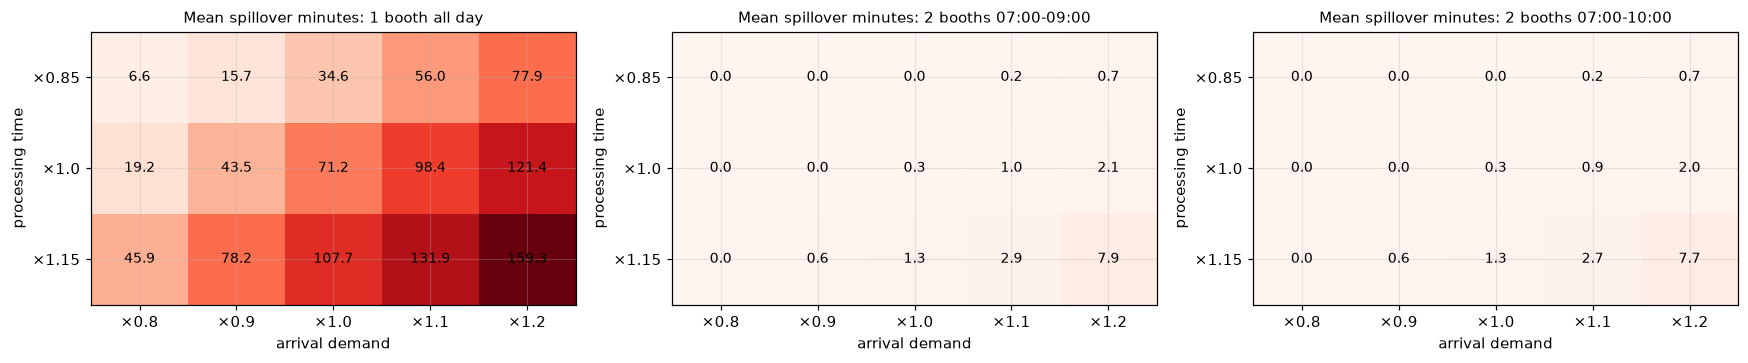

In [22]:
A_SCALES, S_SCALES = [0.8, 0.9, 1.0, 1.1, 1.2], [0.85, 1.0, 1.15]
SENS_COLS = ["avg_wait_min", "spillover_min", "max_queue_veh", "utilization"]
sens, sens_cfg = [], []
for a_s in A_SCALES:
    for s_s in S_SCALES:
        d = ps.run_experiment(SEEDS, rates, SERVICE.with_scale(s_s), K, arrival_scale=a_s)
        by = {c.name: d[d.config == c.name].set_index("seed").sort_index() for c in ps.CONFIGS}
        for cfg, sub in by.items():
            for col in SENS_COLS:
                ci = ps.ci_mean(sub[col])
                sens_cfg.append({"arrival_scale": a_s, "service_scale": s_s, "configuration": cfg, "measure": col,
                                 "mean": ci["mean"], "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})
        for a, b in ps.COMPARISONS:
            for col in SENS_COLS:
                ci = ps.ci_mean(by[a.name][col] - by[b.name][col])
                sens.append({"arrival_scale": a_s, "service_scale": s_s, "comparison": f"{a.name} - {b.name}", "measure": col,
                             "mean_A": by[a.name][col].mean(), "mean_B": by[b.name][col].mean(),
                             "diff": ci["mean"], "diff_ci_low": ci["ci_low"], "diff_ci_high": ci["ci_high"]})
sens, sens_cfg = pd.DataFrame(sens), pd.DataFrame(sens_cfg)
sens.to_csv(RESULTS / "sensitivity_arrival_service.csv", index=False)

sp_cfg = sens_cfg[sens_cfg.measure == "spillover_min"]
fig, axes = plt.subplots(1, len(ps.CONFIGS), figsize=(16, 3.4))
for ax, cfg in zip(axes, [c.name for c in ps.CONFIGS]):
    piv = sp_cfg[sp_cfg.configuration == cfg].pivot(index="service_scale", columns="arrival_scale", values="mean")
    ax.imshow(piv.values, cmap="Reds", vmin=0, vmax=sp_cfg["mean"].max(), aspect="auto")
    for r in range(piv.shape[0]):
        for c in range(piv.shape[1]):
            ax.text(c, r, f"{piv.values[r, c]:.1f}", ha="center", va="center", fontsize=9)
    ax.set_xticks(range(len(A_SCALES))); ax.set_xticklabels([f"×{a}" for a in A_SCALES]); ax.set_xlabel("arrival demand")
    ax.set_yticks(range(len(S_SCALES))); ax.set_yticklabels([f"×{s}" for s in S_SCALES]); ax.set_ylabel("processing time")
    ax.set_title(f"Mean spillover minutes: {cfg}", fontsize=10)
plt.tight_layout(); plt.savefig(FIGS / "sensitivity_spillover.png"); plt.show()

#### Demand scenarios: low (×0.8), expected (×1.0), high (×1.2)
The row of the grid with processing time at ×1.0 gives the three demand scenarios directly: each configuration under −20%, expected, and +20% arrival demand. No extra runs are needed. The second table asks the operational question at each demand level: what does the extra hour (07–10 instead of 07–09) buy?

In [23]:
DEMAND = {0.8: "low (-20%)", 1.0: "expected", 1.2: "high (+20%)"}
dem = sens_cfg[(sens_cfg.service_scale == 1.0) & sens_cfg.arrival_scale.isin(DEMAND)].copy()
dem["demand"] = dem["arrival_scale"].map(DEMAND)
dem["estimate"] = dem.apply(lambda r: f"{r['mean']:.2f} [{r['ci_low']:.2f}, {r['ci_high']:.2f}]", axis=1)
dem.drop(columns="estimate").to_csv(RESULTS / "demand_scenarios.csv", index=False)
display(dem.pivot_table(index=["measure", "configuration"], columns="arrival_scale", values="estimate", aggfunc="first")
           .rename(columns=DEMAND))

extra_hour = sens[(sens.service_scale == 1.0) & sens.arrival_scale.isin(DEMAND)
                  & (sens.comparison == f"{ps.TWO_BOOTH_PEAK.name} - {ps.TWO_BOOTH_EXTENDED.name}")].copy()
extra_hour["demand"] = extra_hour["arrival_scale"].map(DEMAND)
extra_hour.to_csv(RESULTS / "extra_hour_by_demand.csv", index=False)
print("What the extra hour (09:00-10:00) buys: (2 booths 07-09) - (2 booths 07-10), 95% paired CI")
extra_hour[["demand", "measure", "mean_A", "mean_B", "diff", "diff_ci_low", "diff_ci_high"]].round(3)

arrival_scale                                 low (-20%)  \
measure       configuration                                
avg_wait_min  1 booth all day          0.73 [0.59, 0.87]   
              2 booths 07:00-09:00     0.07 [0.07, 0.08]   
              2 booths 07:00-10:00     0.06 [0.06, 0.07]   
max_queue_veh 1 booth all day        11.13 [9.43, 12.84]   
              2 booths 07:00-09:00     3.43 [3.20, 3.67]   
              2 booths 07:00-10:00     3.37 [3.12, 3.62]   
spillover_min 1 booth all day       19.21 [14.37, 24.05]   
              2 booths 07:00-09:00     0.00 [0.00, 0.00]   
              2 booths 07:00-10:00     0.00 [0.00, 0.00]   
utilization   1 booth all day          0.25 [0.24, 0.25]   
              2 booths 07:00-09:00     0.21 [0.21, 0.22]   
              2 booths 07:00-10:00     0.20 [0.19, 0.20]   

arrival_scale                                   expected  \
measure       configuration                                
avg_wait_min  1 booth all day          2.72 [2.32, 3.12]   
              2 booths 07:00-09:00     0.11 [0.10, 0.12]   
              2 booths 07:00-10:00     0.10 [0.09, 0.11]   
max_queue_veh 1 booth all day       26.80 [24.20, 29.40]   
              2 booths 07:00-09:00     4.63 [4.22, 5.04]   
              2 booths 07:00-10:00     4.63 [4.22, 5.04]   
spillover_min 1 booth all day       71.19 [64.84, 77.54]   
              2 booths 07:00-09:00     0.33 [0.03, 0.64]   
              2 booths 07:00-10:00     0.33 [0.03, 0.63]   
utilization   1 booth all day          0.31 [0.30, 0.31]   
              2 booths 07:00-09:00     0.26 [0.26, 0.27]   
              2 booths 07:00-10:00     0.25 [0.24, 0.25]   

arrival_scale                                   high (+20%)  
measure       configuration                                  
avg_wait_min  1 booth all day             6.95 [6.20, 7.70]  
              2 booths 07:00-09:00        0.17 [0.15, 0.20]  
              2 booths 07:00-10:00        0.15 [0.13, 0.18]  
max_queue_veh 1 booth all day          49.67 [45.82, 53.52]  
              2 booths 07:00-09:00        6.30 [5.47, 7.13]  
              2 booths 07:00-10:00        6.30 [5.47, 7.13]  
spillover_min 1 booth all day       121.40 [115.62, 127.19]  
              2 booths 07:00-09:00        2.07 [0.64, 3.50]  
              2 booths 07:00-10:00        2.01 [0.58, 3.44]  
utilization   1 booth all day             0.37 [0.36, 0.38]  
              2 booths 07:00-09:00        0.32 [0.31, 0.32]  
              2 booths 07:00-10:00        0.30 [0.29, 0.30]

What the extra hour (09:00-10:00) buys: (2 booths 07-09) - (2 booths 07-10), 95% paired CI


,demand,measure,mean_A,mean_B,diff,diff_ci_low,diff_ci_high
20,low (-20%),avg_wait_min,0.073,0.060,0.013,0.010,0.015
21,low (-20%),spillover_min,0.000,0.000,0.000,0.000,0.000
22,low (-20%),max_queue_veh,3.433,3.367,0.067,-0.028,0.161
23,low (-20%),utilization,0.210,0.196,0.014,0.014,0.014
92,expected,avg_wait_min,0.113,0.099,0.014,0.010,0.018
93,expected,spillover_min,0.334,0.331,0.003,-0.003,0.010
94,expected,max_queue_veh,4.633,4.633,0.000,0.000,0.000
95,expected,utilization,0.264,0.246,0.018,0.017,0.018
164,high (+20%),avg_wait_min,0.172,0.153,0.019,0.014,0.023
165,high (+20%),spillover_min,2.072,2.011,0.061,-0.062,0.184


### 8.2 Choice of processing-time distribution (same U values, different family)

In [24]:
fam_rows = []
for fam in ps.CANDIDATES:
    sm = service_model(fam)
    d = ps.run_experiment(SEEDS, rates, sm, K)
    for cfg in [c.name for c in ps.CONFIGS]:
        sub = d[d.config == cfg]
        for col in ["avg_wait_min", "spillover_min"]:
            ci = ps.ci_mean(sub[col])
            fam_rows.append({"family": fam, "selected": all(chosen[w] == fam for w in chosen), "configuration": cfg,
                             "measure": col, "mean": ci["mean"], "ci_low": ci["ci_low"], "ci_high": ci["ci_high"]})
fam_df = pd.DataFrame(fam_rows); fam_df.to_csv(RESULTS / "sensitivity_distribution.csv", index=False)
fam_df.pivot_table(index=["measure", "configuration"], columns="family", values="mean").round(3)

family                              exponential  lognormal  triangular
measure       configuration                                           
avg_wait_min  1 booth all day             3.409      2.720       5.555
              2 booths 07:00-09:00        0.188      0.113       0.175
              2 booths 07:00-10:00        0.162      0.099       0.155
spillover_min 1 booth all day            76.189     71.189     105.126
              2 booths 07:00-09:00        1.753      0.334       1.201
              2 booths 07:00-10:00        1.721      0.331       1.173

### 8.3 Approach capacity *K* ± 1 vehicle (same runs, different threshold)

In [25]:
kcols = {f"K={max(K-1,1)}": f"spillover_min_K{max(K-1,1)}", f"K={K}": "spillover_min", f"K={K+1}": f"spillover_min_K{K+1}"}
k_df = pd.DataFrame({lab: exp_df.groupby("config")[col].mean() for lab, col in kcols.items()})
k_df.to_csv(RESULTS / "sensitivity_K.csv"); k_df.round(2)

,K=4,K=5,K=6
config,,,
1 booth all day,75.45,71.19,67.28
2 booths 07:00-09:00,1.20,0.33,0.07
2 booths 07:00-10:00,1.16,0.33,0.07


## 9. Result statement and evidence summary

In [26]:
def p(a, b, col):
    return paired[(paired.comparison == f"{a.name} - {b.name}") & (paired.measure == MEASURES[col][0])].iloc[0]
def s(cfg, col): return summary[(summary.configuration == cfg.name) & (summary.measure == MEASURES[col][0])].iloc[0]
ONE, T9, T10 = ps.ONE_BOOTH, ps.TWO_BOOTH_PEAK, ps.TWO_BOOTH_EXTENDED
sp = sens[sens.measure == "spillover_min"]
sp_main = sp[sp.comparison == f"{ONE.name} - {T9.name}"]
sp_hour = sp[sp.comparison == f"{T9.name} - {T10.name}"]
wins = int((sp_main["diff_ci_low"] > 0).sum())
hour_wins = int((sp_hour["diff_ci_low"] > 0).sum())
hw, hs = p(T9, T10, "avg_wait_min"), p(T9, T10, "spillover_min")

text = (f"Over {N_REPS} replicated high-traffic days (terminating study, 07:00 to queue cleared, no warm-up, seeds 1-{N_REPS}, "
        f"common random numbers), one booth gave a mean wait of {s(ONE, 'avg_wait_min')['mean']:.2f} min "
        f"(95% CI {s(ONE, 'avg_wait_min')['ci_low']:.2f} to {s(ONE, 'avg_wait_min')['ci_high']:.2f}) and "
        f"{s(ONE, 'spillover_min')['mean']:.1f} min of spillover onto Pablo Ocampo Sr. Extension "
        f"(95% CI {s(ONE, 'spillover_min')['ci_low']:.1f} to {s(ONE, 'spillover_min')['ci_high']:.1f}). "
        f"A second booth from 07:00 to 09:00 gave {s(T9, 'avg_wait_min')['mean']:.2f} min mean wait and "
        f"{s(T9, 'spillover_min')['mean']:.1f} min of spillover; the paired reduction in spillover is "
        f"{p(ONE, T9, 'spillover_min')['diff_mean']:.1f} min (95% CI {p(ONE, T9, 'spillover_min')['diff_ci_low']:.1f} "
        f"to {p(ONE, T9, 'spillover_min')['diff_ci_high']:.1f}). "
        f"Keeping the second booth open until 10:00 changed mean wait by a further {hw['diff_mean'] * 60:.1f} s "
        f"(95% CI {hw['diff_ci_low'] * 60:.1f} to {hw['diff_ci_high'] * 60:.1f} s) and spillover by {hs['diff_mean']:.2f} min "
        f"(95% CI {hs['diff_ci_low']:.2f} to {hs['diff_ci_high']:.2f}), at the cost of one more attendant-hour. "
        f"{int(ver['pass'].sum())}/{len(ver)} verification checks passed. Across arrival demand ±20% and processing time ±15%, "
        f"the 07-09 second booth reduced spillover significantly in {wins} of {len(sp_main)} cells, and the extra hour to 10:00 "
        f"reduced it significantly in {hour_wins} of {len(sp_hour)}.")
print(text)
if PLACEHOLDER:
    print("\n[PLACEHOLDER INPUTS - illustrative only. Replace data/ with field observations before reporting.]")

evidence = pd.DataFrame([
    ["Precision", "Mean with 95% CI and n", f"n = {N_REPS} per configuration; paired CIs on three differences (Bonferroni column included)"],
    ["Study design", "Type, run length, warm-up, seeds", f"Terminating, 07:00 to clearance, no warm-up, seeds 1-{N_REPS}, CRN, 3 configurations"],
    ["Verification", "Checks run and passed", f"{int(ver['pass'].sum())}/{len(ver)} (results/verification_checks.csv); continuous fluid-model cross-check of the queue profile (5.5)"],
    ["Validation", "Comparison with real data", "Pending field snapshots" if pd.to_numeric(pd.read_csv(DATA / 'validation_observations.csv')['queue_length_observed'], errors='coerce').isna().all() else "results/validation_comparison.csv"],
    ["Sensitivity", "Does the advice survive input changes?", f"Arrival demand ±20% × processing time ±15%: 07-09 booth cuts spillover significantly in {wins}/{len(sp_main)} cells, extra hour in {hour_wins}/{len(sp_hour)}; distribution family and K±1 in 8.2-8.3"],
], columns=["evidence", "what to show", "this study"])
evidence.to_csv(RESULTS / "evidence_summary.csv", index=False); evidence

Over 30 replicated high-traffic days (terminating study, 07:00 to queue cleared, no warm-up, seeds 1-30, common random numbers), one booth gave a mean wait of 2.72 min (95% CI 2.32 to 3.12) and 71.2 min of spillover onto Pablo Ocampo Sr. Extension (95% CI 64.8 to 77.5). A second booth from 07:00 to 09:00 gave 0.11 min mean wait and 0.3 min of spillover; the paired reduction in spillover is 70.9 min (95% CI 64.5 to 77.2). Keeping the second booth open until 10:00 changed mean wait by a further 0.8 s (95% CI 0.6 to 1.1 s) and spillover by 0.00 min (95% CI -0.00 to 0.01), at the cost of one more attendant-hour. 11/11 verification checks passed. Across arrival demand ±20% and processing time ±15%, the 07-09 second booth reduced spillover significantly in 15 of 15 cells, and the extra hour to 10:00 reduced it significantly in 0 of 15.

[PLACEHOLDER INPUTS - illustrative only. Replace data/ with field observations before reporting.]


,evidence,what to show,this study
0,Precision,Mean with 95% CI and n,n = 30 per configuration; paired CIs on three ...
1,Study design,"Type, run length, warm-up, seeds","Terminating, 07:00 to clearance, no warm-up, s..."
2,Verification,Checks run and passed,11/11 (results/verification_checks.csv); conti...
3,Validation,Comparison with real data,Pending field snapshots
4,Sensitivity,Does the advice survive input changes?,Arrival demand ±20% × processing time ±15%: 07...


### Limitations
- **Arrival data from one day.** Each 15-minute rate rests on a single count. Several high-traffic days would tighten the rates; section 8.1 shows how much the answer moves if demand is off by ±20%.
- **±20% scales the whole day uniformly.** It tests a busier or quieter day with the same shape. It does not test a peak that starts later or lasts past 09:00, which is exactly the case where keeping the second booth until 10:00 would pay off. If field data show demand above one booth's capacity after 09:00, the 07–10 comparison should be revisited.
- **Gate-log censoring.** Unless the peak tally file is filled in, peak arrival rates come from booth passages and understate demand. The true one-booth congestion may then be worse than reported.
- **Shared-queue assumption (A3).** If the approach forms two separate lanes and drivers pick one, two-booth performance will be somewhat worse than modelled.
- **Empty start at 07:00 (A7).** If vehicles queue before the booth opens, the morning is under-estimated. Record the queue at 07:00 on the observation day.
- **No balking or reneging.** Real drivers facing a long line may divert, which would lower the queue but also represents lost entries. This is out of scope per the proposal.
- The model estimates queueing performance only. Whether the reduction justifies an extra attendant is a management judgment about cost, which the proposal leaves outside the model.